# Fano factor vs LDA (trimmed, with trial/neuron/session QC filters)
Stripped-down version of `ff_psth_ldabin.ipynb`: keeps only what's needed to test the single-neuron
Fano factor (baseline, post-stimulus, quench magnitude, quench onset time) against an LDA
dimension, plus one descriptive PSTH plot. Removed relative to `ff_psth_ldabin.ipynb`: the
per-region plot grids, the baseline-subtracted/shaded-window plot grids, and the whole
mean-matched-Fano-factor (Churchland et al. 2010) control section.

New relative to `ff_psth_ldabin.ipynb` -- three QC filters, applied in this order:
1. **Session eligibility** (behavioral, before any neural data is touched): drop sessions with
   fewer than `SESSION_MIN_TRIALS` total trials or fewer than `SESSION_MIN_ERROR_TRIALS` incorrect
   trials -- the latter guards against sessions with too little behavioral variability to say
   anything about error/engagement-related effects.
2. **Trial filtering**: drop trials whose reaction time falls outside `RT_WINDOW` (very fast RTs
   are likely anticipatory/non-decision, very slow ones likely disengaged/lapse trials), then cap
   the remaining trial count at `TRIAL_CAP` (random subsample) so no single session with unusually
   many trials dominates the pooled statistics.
3. **Neuron filtering**: drop neurons whose mean firing rate (over the RT-valid trials, full
   trial epoch) is below `MIN_NEURON_FR_HZ`.

The predictor is configurable via `PREDICTOR_DIM` (0-indexed column in the LDA clustering table --
0 is LDA-1) so any LDA dimension can be tested, not just the first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
from scipy.stats import pearsonr
from iblatlas.regions import BrainRegions
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white'

In [92]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/data_files/'
data_dir = prefix + 'data/'

REGION_LEVEL = 'beryl'    # 'cosmos' | 'beryl'
DROP = ['void']  # , 'root'
KEEP = labels = ['CA1', 'DG', 'MRN', 'CP', 'LP', 'CA3', 'ZI', 'PO', 'MOs', 'MOp', 'root', 'void', 
                 'APN', 'SCm', 'IRN', 'VPM', 'PAG', 'VISa', 'LSr', 'CUL4', 'MD', 'VISp', 'PIR', 'LD',
                 'RSPv', 'SI', 'SUB', 'RT' , 'PRM', 'RSPd', 'Eth', 'ANcr2', 'ACB', 'CENT3', 'IC', 'IP', 
                 'SSp-bfd', 'PB', 'LGd', 'VPL', 'VISam', 'NOT', 'NTS', 'ACAd', 'VM', 'SPVI', 'RSPagl', 
                 'CA2', 'LH', 'GPe', 'GRN', 'PARN', 'SCs', 'PoT'
                ]
WIN_BINS = 6               # ~100 ms sliding window, descriptive PSTH plot only
SMOOTH_MODE = 'causal'     # 'causal' (only bins <= t) or 'centered'
MIN_NEURONS = 15           # per region in a session, after neuron/trial filtering below
N_BINS = 5                 # LDA bins, descriptive PSTH plot only
REMOVE_CONDITION = True    # subtract stimulus (side x contrast) means before variance (mean-matched FF)
MIN_MEAN_COUNT = 0.01      # per-bin mean-count floor, descriptive curve only (FF unstable at low counts)
CORRECT_ONLY = False       # if True, use only correct trials in the FF computation itself
SEED = 0

PREDICTOR_DIM = 0          # 0-indexed LDA column to test (0 = LDA-1, 1 = LDA-2, ...); renamed 'lda_1' below regardless
LDA_FILE = 'mouse_LDA_5_bins_cut19-08-2026'   # 'mouse_LDA_5_bins_cut06-07-2026' used elsewhere isn't on this machine

# --- paper-style single-neuron Fano factor (fixed pre-/post-stimulus windows, no smoothing) ---
PRE_WINDOW = (-0.2, 0.0)    # baseline window (s)
POST_WINDOW = (0.1, 0.3)    # post-stimulus window (s)
MIN_TRIALS = 40             # min complete trials per session-region, after filtering, to trust a window FF estimate
MIN_WINDOW_COUNT = 0.5      # min mean spike count within the window (FF unstable below this)
N_PERM = 2000               # permutation iterations (matches the paper's neural-metric count)

# --- new QC filters ---
SESSION_MIN_TRIALS = 400        # session-level: drop sessions with fewer total behavioral trials
SESSION_MIN_ERROR_TRIALS = 3    # session-level: drop sessions with fewer incorrect trials
RT_WINDOW = (0.08, 2.0)         # trial-level: keep only trials with reaction time in this range (s)
TRIAL_CAP = 400                 # trial-level: cap trials per session at this many (random subsample)
MIN_NEURON_FR_HZ = 1.0          # neuron-level: drop neurons below this mean firing rate (Hz)
GOCUE_TOL = 0.01                # seconds - tolerance for validating trial_id alignment against ONE

# --- quench onset (per-neuron derivative-threshold onset latency), unchanged from ff_psth_ldabin.ipynb ---
SEARCH_WINDOW = (-0.2, 0.2)
PEAK_SEARCH_WINDOW = (-0.05, 0.08)
ONSET_THRESHOLD_FRAC = 0.25
SMOOTH_SIGMA = 1.0

## Load LDA clustering + behavioral trial metadata

In [93]:
lda_raw = pd.read_pickle(clustering_dir + LDA_FILE)
lda = lda_raw.rename(columns={PREDICTOR_DIM: 'lda_1'})[['session', 'lda_1']].copy()
lda['bin'] = pd.qcut(lda['lda_1'], N_BINS, labels=False, duplicates='drop')
bin_map = dict(zip(lda['session'], lda['bin']))
lda1_map = dict(zip(lda['session'], lda['lda_1']))
print(f"Testing raw LDA column {PREDICTOR_DIM} (renamed 'lda_1') | {lda['session'].nunique()} sessions")

trials_df = pd.read_parquet(prefix + '4_mice/' + 'session_trial_meta_19-08-2026')
correct_by_session = trials_df[trials_df['feedback'] == 'correct'].groupby('session')['trial_id'].apply(set).to_dict()
gocue_by_session = {s: g.set_index('trial_id')['goCueTrigger_times']
                    for s, g in trials_df.groupby('session')}
reaction_by_session = {s: g.set_index('trial_id')['reaction']
                       for s, g in trials_df.groupby('session')}
br = BrainRegions()

Testing raw LDA column 0 (renamed 'lda_1') | 271 sessions


## Session-level filter
Drop sessions with too few total trials or too few error trials -- a pure behavioral QC gate,
computed once up front from `trials_df` so ineligible sessions' (large) pkl files never get opened.

In [94]:
session_n_trials = trials_df.groupby('session')['trial_id'].nunique()
session_n_errors = (trials_df[trials_df['feedback'] != 'correct']
                     .groupby('session')['trial_id'].nunique().reindex(session_n_trials.index, fill_value=0))

eligible_sessions = set(session_n_trials.index[(session_n_trials >= SESSION_MIN_TRIALS) &
                                                (session_n_errors >= SESSION_MIN_ERROR_TRIALS)])
print(f"{len(eligible_sessions)}/{len(session_n_trials)} sessions pass the session-level filter "
      f"(>= {SESSION_MIN_TRIALS} trials, >= {SESSION_MIN_ERROR_TRIALS} error trials)")

255/255 sessions pass the session-level filter (>= 400 trials, >= 3 error trials)


## Fano-factor helper functions (unchanged from `ff_psth_ldabin.ipynb`)

In [95]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)
binwidth = float(np.median(np.diff(tsec)))
pre_mask = (tsec >= PRE_WINDOW[0]) & (tsec < PRE_WINDOW[1])
post_mask = (tsec >= POST_WINDOW[0]) & (tsec < POST_WINDOW[1])
search_mask = (tsec >= SEARCH_WINDOW[0]) & (tsec <= SEARCH_WINDOW[1])
t_search = tsec[search_mask]
peak_search_local_mask = (t_search >= PEAK_SEARCH_WINDOW[0]) & (t_search <= PEAK_SEARCH_WINDOW[1])
_search_idx = np.where(search_mask)[0]
_pad_bins = int(4 * SMOOTH_SIGMA) + 1
_pad_lo = max(0, _search_idx[0] - _pad_bins)
_pad_hi = min(T, _search_idx[-1] + 1 + _pad_bins)
pad_mask = np.zeros(T, dtype=bool); pad_mask[_pad_lo:_pad_hi] = True
_pad_offset = _search_idx[0] - _pad_lo

def smooth_time(A, W, mode):
    if mode == 'centered':
        return uniform_filter1d(A, W, axis=2, mode='nearest')
    if mode == 'leading':
        # Forward-looking window: value at t uses bins [t, t+W) -- needed for the quench-onset
        # timing to match ff_quench.ipynb's "## Timing of quench onset" section.
        c = np.cumsum(A, axis=2); Tn = A.shape[2]; out = np.empty_like(A)
        out[..., :Tn - W] = (c[..., W:] - c[..., :Tn - W]) / W
        for k in range(W):
            idx = Tn - W + k
            prev = c[..., idx - 1] if idx > 0 else 0.0
            out[..., idx] = (c[..., -1] - prev) / (Tn - idx)
        return out
    c = np.cumsum(A, axis=2); out = np.empty_like(A)
    out[..., :W] = c[..., :W] / np.arange(1, W + 1)
    out[..., W:] = (c[..., W:] - c[..., :-W]) / W
    return out

def ff_curve(A, cond=None):
    """A: neurons x trials x T (windowed spike counts). Condition-adjusted mean Fano factor per
    time bin, averaged across neurons -- descriptive PSTH plot only."""
    mean = np.nanmean(A, axis=1)
    if REMOVE_CONDITION and cond is not None:
        resid = A.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(A, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= MIN_MEAN_COUNT) | ~np.isfinite(ff)] = np.nan
    return np.nanmean(ff, axis=0)

def window_ff(counts, cond):
    """counts: neurons x trials, window-summed spike counts for a single fixed window. Per-neuron
    condition-adjusted (mean-matched) Fano factor -- the paper's single-neuron FF metric."""
    mean = np.nanmean(counts, axis=1)
    if REMOVE_CONDITION:
        resid = counts.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            resid[:, ci] -= np.nanmean(counts[:, ci], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(counts, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= MIN_WINDOW_COUNT) | ~np.isfinite(ff)] = np.nan
    return ff

def neuron_ff_timecourse(A, cond, min_count):
    """Same mean-matched Fano factor as ff_curve/window_ff, kept per-neuron AND per-time-bin --
    used to find each neuron's own FF peak/trough for the quench-onset metric."""
    mean = np.nanmean(A, axis=1)
    if REMOVE_CONDITION:
        resid = A.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(A, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= min_count) | ~np.isfinite(ff)] = np.nan
    return ff

_functional_cache = {}
def functional_group_map(area_acronyms):
    """Ad-hoc region grouping used as the quench-onset region covariate (matches
    ff_psth_ldabin.ipynb / ff_quench.ipynb): singles out Hippocampus/Thalamus/Visual/Motor/
    Somatosensory cortex by name/ancestry, falls back to the Cosmos parent otherwise."""
    unique_areas = [a for a in pd.unique(area_acronyms) if a not in _functional_cache
                    and not (isinstance(a, float) and np.isnan(a))]
    if unique_areas:
        cosmos_map = dict(zip(unique_areas, br.acronym2acronym(unique_areas, mapping='Cosmos')))
        for a in unique_areas:
            try:
                ancestor_acronyms = br.ancestors(ids=br.acronym2id(a))['acronym']
                if 'TH' in ancestor_acronyms or a in ['PO', 'LP']:
                    _functional_cache[a] = 'Thalamus'
                elif 'HPF' in ancestor_acronyms or a in ['CA1', 'DG']:
                    _functional_cache[a] = 'Hippocampus'
                elif 'Isocortex' in ancestor_acronyms and any(v in a for v in ['VIS', 'RSP']):
                    _functional_cache[a] = 'Visual Cortex'
                elif 'Isocortex' in ancestor_acronyms:
                    if any(m in a for m in ['MOp', 'MOs', 'MO']):
                        _functional_cache[a] = 'Motor Cortex'
                    elif any(s in a for s in ['SSp', 'SSs', 'SS']):
                        _functional_cache[a] = 'Somatosensory Cortex'
                    else:
                        _functional_cache[a] = 'Other Cortex'
                else:
                    _functional_cache[a] = cosmos_map.get(a, 'Other')
            except Exception:
                _functional_cache[a] = cosmos_map.get(a, 'Unassigned')
    return pd.Series(area_acronyms).map(_functional_cache).values

## Main compute loop: session/trial/neuron filters + descriptive curve + single-neuron pre/post/quench/onset
Trial filtering order per session: (1) validate the pkl file's own `event_time` against ONE's
`goCueTrigger_times` at the same `trial_id` -- the reaction-time filter below depends on this join
being correct, so a mismatching session is skipped entirely, same safeguard
`noise_corr_psth_lda.ipynb` uses; (2) keep only trials with reaction time inside `RT_WINDOW`;
(3) cap at `TRIAL_CAP` trials (random subsample) so this is decided once per session and shared by
every region in it, exactly as the original's `valid_idx` was. The neuron firing-rate filter is
computed on the RT-valid trials *before* the trial cap, so a neuron's inclusion doesn't depend on
which random 400 trials happened to be kept.

In [96]:
rng = np.random.default_rng(SEED)
records = []
neuron_records = []
onset_records = []
n_session_mismatch = 0
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        d = d[d['area'].isin(KEEP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        if session not in bin_map or session not in eligible_sessions: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}

        # Validate the trial_id join against ONE before trusting reaction_by_session for this
        # session (same check noise_corr_psth_lda.ipynb uses for goCueTrigger_times).
        gocue = gocue_by_session.get(session)
        if gocue is None: continue
        own_event_time = d.drop_duplicates('trial_id').set_index('trial_id')['event_time'].reindex(trials)
        one_event_time = gocue.reindex(trials)
        mismatch = (own_event_time - one_event_time).abs() > GOCUE_TOL
        if mismatch.any():
            n_session_mismatch += 1
            continue

        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values * binwidth

        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        neu_functional = functional_group_map(na.values)

        conds = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials).values
        corr_set = correct_by_session.get(session, set())
        correct_mask = np.array([t in corr_set for t in trials]) if CORRECT_ONLY else np.ones(len(trials), dtype=bool)

        reaction = reaction_by_session.get(session)
        rt = reaction.reindex(trials).values if reaction is not None else np.full(len(trials), np.nan)
        rt_mask = np.isfinite(rt) & (rt >= RT_WINDOW[0]) & (rt <= RT_WINDOW[1])

        rt_valid_idx = np.where(correct_mask & rt_mask)[0]
        if len(rt_valid_idx) == 0: continue

        # Neuron firing-rate filter, on the RT-valid trials (pre-cap: a neuron's admission
        # shouldn't hinge on which random 400-trial subsample happened to be drawn).
        fr_hz = np.nanmean(A[:, rt_valid_idx, :], axis=(1, 2)) / binwidth
        fr_ok = np.isfinite(fr_hz) & (fr_hz >= MIN_NEURON_FR_HZ)

        valid_idx = rt_valid_idx if len(rt_valid_idx) <= TRIAL_CAP else \
            np.sort(rng.choice(rt_valid_idx, TRIAL_CAP, replace=False))

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where((neu_area == region) & fr_ok)[0]
            if len(ni) < MIN_NEURONS: continue

            Asub = A[ni]
            complete = ~np.isnan(Asub).any(axis=(0, 2))
            comp_idx = valid_idx[complete[valid_idx]]
            if len(comp_idx) < MIN_NEURONS: continue

            # --- descriptive PSTH curve (region-averaged) ---
            Aw = smooth_time(Asub[:, comp_idx, :], WIN_BINS, SMOOTH_MODE) * WIN_BINS
            curve = ff_curve(Aw, conds[comp_idx])
            records.append(dict(session=session, region=region, bin=bin_map[session],
                                n_neurons=len(ni), n_trials=len(comp_idx), curve=curve))

            # --- paper-style single-neuron pre-/post-stimulus window Fano factor ---
            if len(comp_idx) >= MIN_TRIALS:
                counts_pre = np.nansum(A[ni][:, comp_idx][:, :, pre_mask], axis=2)
                counts_post = np.nansum(A[ni][:, comp_idx][:, :, post_mask], axis=2)
                cond_valid = conds[comp_idx]
                ff_pre = window_ff(counts_pre, cond_valid)
                ff_post = window_ff(counts_post, cond_valid)
                keep = np.isfinite(ff_pre) & np.isfinite(ff_post)
                for nu, fp, po in zip(np.array(neurons)[ni][keep], ff_pre[keep], ff_post[keep]):
                    neuron_records.append(dict(session=session, region=region, nuid=nu,
                                               n_trials=len(comp_idx), ff_pre=fp, ff_post=po,
                                               ff_quench=fp - po))

                # --- quench onset: derivative-threshold onset latency (unchanged algorithm) ---
                Aw_neu = smooth_time(A[ni][:, comp_idx, :], WIN_BINS, 'leading') * WIN_BINS
                ff_t_pad = neuron_ff_timecourse(Aw_neu[:, :, pad_mask], cond_valid, MIN_MEAN_COUNT)
                finite_rows = np.all(np.isfinite(ff_t_pad), axis=1)
                if finite_rows.any() and peak_search_local_mask.any():
                    ff_smooth_pad = gaussian_filter1d(ff_t_pad[finite_rows], sigma=SMOOTH_SIGMA, axis=1)
                    ff_t_smooth = ff_smooth_pad[:, _pad_offset:_pad_offset + len(t_search)]
                    nu_ok = np.array(neurons)[ni][finite_rows]
                    func_ok = neu_functional[ni][finite_rows]
                    for row_i in range(ff_t_smooth.shape[0]):
                        ts_win = ff_t_smooth[row_i]
                        i_peak_local = np.argmax(ts_win[peak_search_local_mask])
                        t_peak = t_search[peak_search_local_mask][i_peak_local]

                        derivative = np.gradient(ts_win, binwidth)
                        after_peak_mask = t_search >= t_peak
                        deriv_after_peak = derivative[after_peak_mask]
                        min_deriv = np.min(deriv_after_peak)
                        onset_threshold = min_deriv * ONSET_THRESHOLD_FRAC
                        onset_candidates = np.where((derivative < onset_threshold) & after_peak_mask)[0]
                        onset_time = t_search[onset_candidates[0]] if len(onset_candidates) else t_peak

                        onset_records.append(dict(session=session, nuid=nu_ok[row_i],
                                                  quench_onset_time=onset_time,
                                                  functional_region=func_ok[row_i]))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

curves = pd.DataFrame(records)
print(f"Descriptive curves: {len(curves)} session-region rows | {curves['session'].nunique()} sessions")
if n_session_mismatch:
    print(f"{n_session_mismatch} pid files skipped due to trial_id/goCueTrigger_times mismatch vs ONE")

neuron_df = pd.DataFrame(neuron_records)
neuron_df['lda_1'] = neuron_df['session'].map(lda1_map)
neuron_df['bin'] = neuron_df['session'].map(bin_map)
neuron_df['log_ff_pre'] = np.log(neuron_df['ff_pre'].clip(lower=1e-6))
neuron_df['log_ff_post'] = np.log(neuron_df['ff_post'].clip(lower=1e-6))

onset_df = pd.DataFrame(onset_records)
neuron_df = neuron_df.merge(onset_df, on=['session', 'nuid'], how='left')
print(f"Single-neuron FF table: {len(neuron_df)} neurons | {neuron_df['session'].nunique()} sessions | "
      f"regions: {neuron_df['region'].nunique()}")
print(f"Quench onset time available for {neuron_df['quench_onset_time'].notna().sum()} of {len(neuron_df)} neurons")

  100/397 files...
  200/397 files...
  300/397 files...
Descriptive curves: 517 session-region rows | 210 sessions
Single-neuron FF table: 12593 neurons | 208 sessions | regions: 47
Quench onset time available for 12589 of 12593 neurons


## PSTH: Fano factor by LDA bin (all regions pooled)

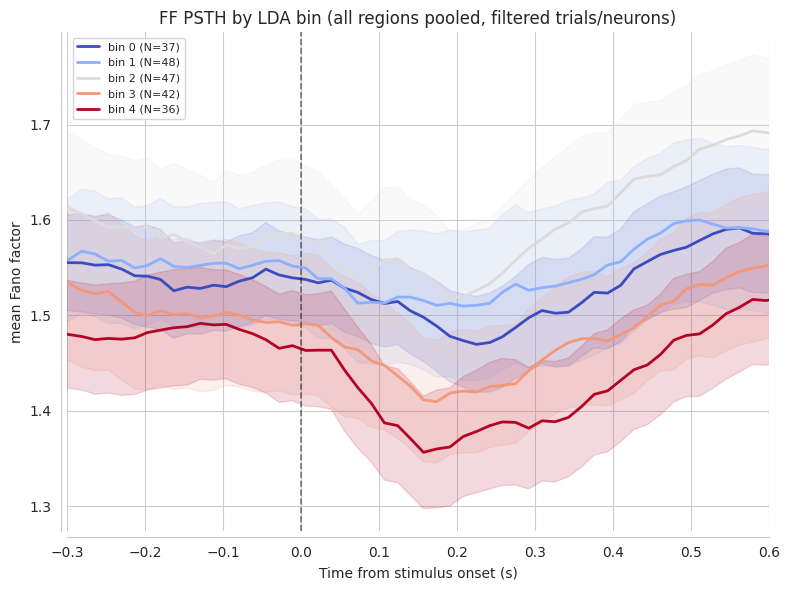

In [97]:
def bins_by_session(df_sub):
    per_sess = (df_sub.groupby(['session', 'bin'])['curve']
                .apply(lambda cs: np.nanmean(np.vstack(cs.values), axis=0)).reset_index())
    return {b: np.vstack(g['curve'].values) for b, g in per_sess.groupby('bin')}

colors = plt.cm.coolwarm(np.linspace(0, 1, N_BINS))
agg = bins_by_session(curves)
fig, ax = plt.subplots(figsize=(8, 6))
xlim = (-0.3, 0.6); xmask = (tsec >= xlim[0]) & (tsec <= xlim[1]); yv = []
for b in range(N_BINS):
    if b not in agg: continue
    M = agg[b]; mean = np.nanmean(M, axis=0)
    ax.plot(tsec, mean, color=colors[b], lw=2, label=f'bin {b} (N={M.shape[0]})')
    if M.shape[0] > 1:
        sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
        ax.fill_between(tsec, mean - sem, mean + sem, color=colors[b], alpha=0.15)
        yv += [(mean - sem)[xmask], (mean + sem)[xmask]]
ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
ax.axhline(1.0, color='gray', ls=':', alpha=0.6)
ax.set_xlabel('Time from stimulus onset (s)'); ax.set_ylabel('mean Fano factor')
ax.set_title('FF PSTH by LDA bin (all regions pooled, filtered trials/neurons)')
ax.set_xlim(list(xlim))
if yv:
    allv = np.concatenate(yv); lo, hi = np.nanmin(allv), np.nanmax(allv)
    pad = 0.05 * (hi - lo) if hi > lo else 0.05 * abs(hi) + 1e-6
    ax.set_ylim(lo - pad, hi + pad)
ax.legend(fontsize=8); sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

## Single-neuron Fano factor vs LDA: GLM + session-permutation test + Bayes factor
Unchanged from `ff_psth_ldabin.ipynb`: GLM slope of `lda_1` as the test statistic, session-stratified
permutation null (n=`N_PERM`), and the partial-correlation JZS Bayes factor
(`pingouin.bayesfactor_pearson`) via Frisch-Waugh-Lovell residualization.

In [98]:
def _design_matrix(df, region_col='region', extra_covars=('n_trials',)):
    dummies = pd.get_dummies(df[region_col], drop_first=True)
    Z = pd.concat([pd.Series(1.0, index=df.index, name='Intercept'), dummies,
                   df[list(extra_covars)].astype(float)], axis=1)
    return Z.values.astype(float)

def age_effect_test(df, y_col, predictor='lda_1', region_col='region', extra_covars=('n_trials',),
                     n_perm=N_PERM, seed=SEED, label=None):
    d = df.dropna(subset=[y_col, predictor, region_col] + list(extra_covars)).reset_index(drop=True)
    y = d[y_col].values.astype(float)
    x = d[predictor].values.astype(float)
    Z = _design_matrix(d, region_col, extra_covars)
    Zpinv = np.linalg.pinv(Z)

    y_resid = y - Z @ (Zpinv @ y)
    x_resid_obs = x - Z @ (Zpinv @ x)
    slope_obs = np.sum(x_resid_obs * y_resid) / np.sum(x_resid_obs ** 2)

    r_partial, _ = pearsonr(x_resid_obs, y_resid)
    n_eff = max(len(d) - (Z.shape[1] - 1), 3)
    bf10 = pg.bayesfactor_pearson(r_partial, n_eff)

    sess_to_x = d.groupby('session')[predictor].first()
    sess_index = d['session'].values
    rng_p = np.random.default_rng(seed)
    perm_slopes = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = pd.Series(rng_p.permutation(sess_to_x.values), index=sess_to_x.index)
        x_perm = shuffled.reindex(sess_index).values.astype(float)
        x_perm_resid = x_perm - Z @ (Zpinv @ x_perm)
        perm_slopes[i] = np.sum(x_perm_resid * y_resid) / np.sum(x_perm_resid ** 2)
    p_perm = np.mean(np.abs(perm_slopes) >= np.abs(slope_obs))

    gdf = d.copy(); gdf['_y'] = y
    formula = f"_y ~ {predictor} + C({region_col}) + " + ' + '.join(extra_covars)
    glm_fit = smf.glm(formula, data=gdf, family=sm.families.Gaussian()).fit()

    return dict(label=label or y_col, n=len(d), n_sessions=d['session'].nunique(),
                slope=slope_obs, r_partial=r_partial, bf10=bf10, p_perm=p_perm,
                glm_slope=glm_fit.params[predictor], glm_p=glm_fit.pvalues[predictor])

def bf_label(bf):
    if bf > 10: return 'strong H1'
    if bf > 3: return 'moderate H1'
    if bf < 1 / 10: return 'strong H0'
    if bf < 1 / 3: return 'moderate H0'
    return 'inconclusive'

In [99]:
results = {
    'FF_pre (log)': age_effect_test(neuron_df, 'log_ff_pre',
                                     label='log FF_pre ~ lda_1 + C(region) + n_trials'),
    'FF_post (log)': age_effect_test(neuron_df, 'log_ff_post',
                                      label='log FF_post ~ lda_1 + C(region) + n_trials'),
    'FF_quench': age_effect_test(neuron_df, 'ff_quench',
                                  label='FF_quench ~ lda_1 + C(region) + n_trials'),
    'Quench onset time': age_effect_test(neuron_df, 'quench_onset_time', region_col='functional_region',
                                          label='Quench_onset_time ~ lda_1 + C(functional_region) + n_trials'),
}

print(f"{'metric':<20}{'n':>7}{'n_sess':>8}{'slope':>10}{'r_partial':>11}{'BF10':>10}{'evidence':>14}{'p_perm':>10}")
for name, r in results.items():
    print(f"{name:<20}{r['n']:>7}{r['n_sessions']:>8}{r['slope']:>10.4f}{r['r_partial']:>11.4f}"
          f"{r['bf10']:>10.3g}{bf_label(r['bf10']):>14}{r['p_perm']:>10.4f}")

metric                    n  n_sess     slope  r_partial      BF10      evidence    p_perm
FF_pre (log)          12593     208   -0.0135    -0.0566  6.26e+06     strong H1    0.0290
FF_post (log)         12593     208   -0.0215    -0.0964  2.82e+23     strong H1    0.0020
FF_quench             12593     208    0.0144     0.0380      95.5     strong H1    0.0635
Quench onset time     12589     208   -0.0011    -0.0532   6.2e+05     strong H1    0.0035


## Fano factor vs LDA (session-averaged for display; test statistics from the GLM above)
Regression lines are only drawn when `BF10 > 3` (moderate-or-better evidence for H1).

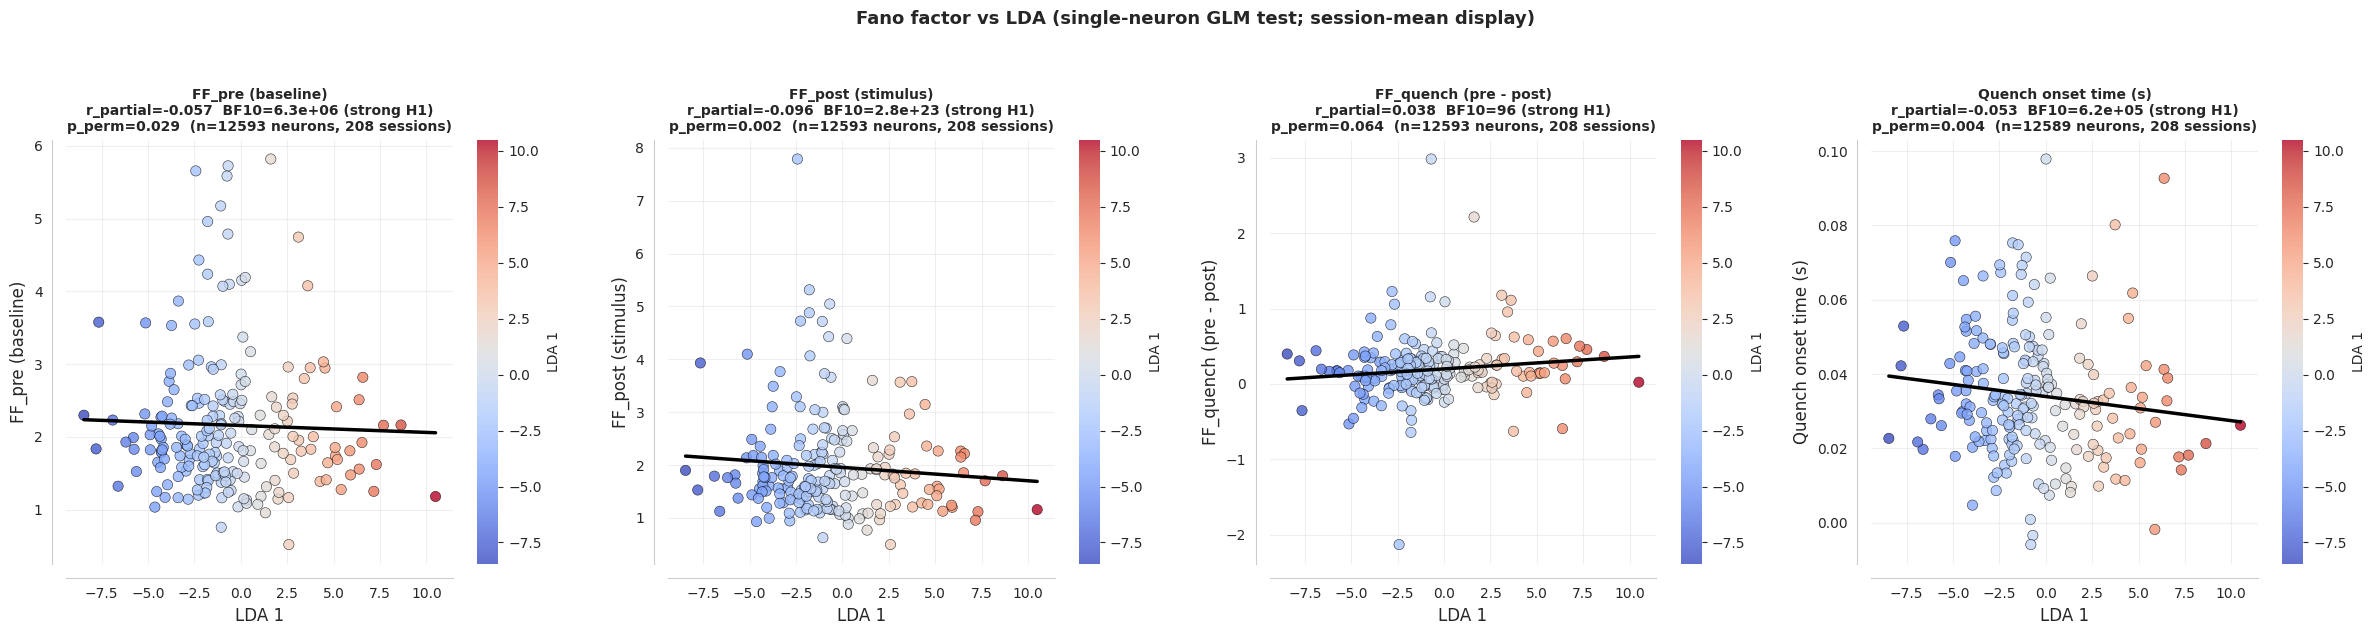

In [100]:
session_ff = neuron_df.groupby('session').agg(
    ff_pre=('ff_pre', 'mean'), ff_post=('ff_post', 'mean'), ff_quench=('ff_quench', 'mean'),
    quench_onset_time=('quench_onset_time', 'mean'), lda_1=('lda_1', 'first')).reset_index()

panels = [('ff_pre', 'FF_pre (baseline)', results['FF_pre (log)']),
          ('ff_post', 'FF_post (stimulus)', results['FF_post (log)']),
          ('ff_quench', 'FF_quench (pre - post)', results['FF_quench']),
          ('quench_onset_time', 'Quench onset time (s)', results['Quench onset time'])]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, (col, title, res) in zip(axes, panels):
    d = session_ff.dropna(subset=[col, 'lda_1'])
    x = d['lda_1'].values; y = d[col].values
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=55, edgecolors='black', linewidth=0.4)
    if res['bf10'] > 3:
        z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
        ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5)
    cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1'); cb.outline.set_visible(False)
    ax.set_xlabel('LDA 1', fontsize=12); ax.set_ylabel(title, fontsize=12)
    ax.set_title(f"{title}\nr_partial={res['r_partial']:.3f}  BF10={res['bf10']:.2g} ({bf_label(res['bf10'])})\n"
                 f"p_perm={res['p_perm']:.3f}  (n={res['n']} neurons, {res['n_sessions']} sessions)",
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=10)
fig.suptitle('Fano factor vs LDA (single-neuron GLM test; session-mean display)', y=1.05, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()